# EDA Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1) Import data

In [2]:
customer=pd.read_csv("C:/New folder/New folder/messy data/messy data/messy_customers.csv")
order_item=pd.read_csv("C:/New folder/New folder/messy data/messy data/messy_order_items.csv")
orders=pd.read_csv("C:/New folder/New folder/messy data/messy data/messy_orders.csv")
product=pd.read_csv("C:/New folder/New folder/messy data/messy data/messy_products.csv")

In [3]:
customer

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


Note: The dataset contains 520 rows containing customer_id, customer_name, city and	signup_date.

In [4]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    520 non-null    str  
 1   customer_name  492 non-null    str  
 2   city           479 non-null    str  
 3   signup_date    520 non-null    str  
dtypes: str(4)
memory usage: 16.4 KB


Note: There are some null values in customer_name and city. There is a column name i.e, signup_date 
which is not in proper form so we have to convert it into the proper form.

In [5]:
customer.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0014,Customer_14,Hyderabad,2023-06-15
freq,2,2,54,4


Note: This function shows stastical summary of columns: customer_id, customer_name, city and signup_date. It provide measures such as count, unique, top and frequency.

In [6]:
customer[customer.duplicated()]

,customer_id,customer_name,city,signup_date
500,C0309,Customer_309,Kolkata,2025-05-09
501,C0014,Customer_14,delhi,2024-08-18
502,C0415,Customer_415,Kolkata,2025-04-05
503,C0033,Customer_33,mumbai,2024-04-30
504,C0461,Customer_461,Chennai,2024-06-02
505,C0156,Customer_156,Pune,2024-08-07
506,C0250,Customer_250,Mumbai,2024-12-31
507,C0218,Customer_218,delhi,2025-02-02
508,C0222,Customer_222,Hyderabad,2024-05-20
509,C0294,Customer_294,Hyderabad,2023-09-12


Note: These are the duplicate values in customer table

In [7]:
order_item

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


Note: The dataset contains 2050 rows containing order_item_id, order_id, product_id,quantity and unit_price.

In [8]:
order_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   str    
 2   product_id     2050 non-null   str    
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 80.2 KB


Note: In this table we have a column with name quantity which is not in a proper form so we have to convert it into a proper form and we also have null values in columns quantity and unit_price.

In [9]:
order_item.describe()

,order_item_id,quantity,unit_price
count,2050.000000,1732.000000,1039.000000
mean,999.866341,1.991339,44956.006737
std,576.435038,1.411120,24978.977806
min,1.000000,0.000000,1072.000000
25%,502.250000,1.000000,23987.000000
50%,998.500000,2.000000,43654.000000
75%,1499.750000,3.000000,65136.500000
max,2000.000000,4.000000,89980.000000


Note: It shows numerical values of columns: order_item_id, quantity and unit_price. It shows measures like count, mean, standard deviation, quartile(25%,50%,75%), minimum and maximum values of the table and it also shows that some values are missing from quantity and unit_price.

In [10]:
order_item[order_item.duplicated()]

,order_item_id,order_id,product_id,quantity,unit_price
2000,689,O01021,P004,0.0,NaN
2001,436,O00386,P012,3.0,31320.0
2002,1596,O00176,P065,1.0,NaN
2003,1775,O00896,P030,3.0,40678.0
2004,1904,O00312,P031,3.0,NaN
2005,1420,O00327,P039,2.0,53326.0
2006,411,O01054,P072,0.0,85189.0
2007,697,O00355,P063,4.0,55126.0
2008,1006,O00750,P041,0.0,NaN
2009,861,O00205,P060,4.0,55826.0


Note: These are the duplicate rows of order_item table.

In [11]:
orders

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


Note: The dataset contains 1240 rows containing order_id, customer_id, order_date and payment_method.

In [12]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1240 non-null   str  
 1   customer_id     1240 non-null   str  
 2   order_date      1240 non-null   str  
 3   payment_method  1095 non-null   str  
dtypes: str(4)
memory usage: 38.9 KB


Note: In this dataset order_date is not in proper format so we have to convert it into proper format and also some values are missing from the column payment_method.

In [13]:
orders.describe()

,order_id,customer_id,order_date,payment_method
count,1240,1240,1240,1095
unique,1200,448,815,7
top,O00015,C0218,2024-02-21,Credit Card
freq,2,10,5,171


Note: It shows statistical summary of columns: order_id, customer_id, order_date and payment_method. It gives measures such as count, unique values, top and frequency values.

In [14]:
orders[orders.duplicated()]

,order_id,customer_id,order_date,payment_method
1200,O00403,C0148,28/10/2024,Debit Card
1201,O00375,C0427,07-03-2024,credit card
1202,O00279,C0286,2024-12-06,Cash
1203,O00015,C0329,02/09/2024,Cash on Delivery
1204,O00147,C0303,06-23-2024,Credit Card
1205,O00186,C0333,2024-09-21,Cash
1206,O01084,C0186,04-11-2024,Cash
1207,O01188,C0094,02/05/2024,UPI
1208,O00350,C0328,27/04/2024,Credit Card
1209,O00526,C0068,04-19-2025,Cash


In [15]:
product


,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


Note: In this table we have 90 rows with column name: product_id, product_name, category and base_price.

In [16]:
product.info()


<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     str    
 1   product_name  90 non-null     str    
 2   category      90 non-null     str    
 3   base_price    33 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.9 KB


Note: In this table we have some missing values in base_price column.

In [17]:
product.describe()

,base_price
count,33.000000
mean,45047.454545
std,25654.215131
min,2571.000000
25%,27157.000000
50%,47453.000000
75%,68660.000000
max,84776.000000


Note: It shows numerical summary of base_price column. It provides measures such as count, mean, standard deviation, quartile(25%, 50%, 75%), minimum and maximum values.

In [18]:
product[product.duplicated()]

,product_id,product_name,category,base_price
80,P076,Wireless Mouse,Accessory,15249.0
81,P062,Dell Inspiron,Tablet,NaN
82,P072,Dell Inspiron,Tablet,NaN
83,P017,Keyboard,Smartphone,NaN
84,P020,Dell Inspiron,Smartphone,NaN
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN
89,P033,Wireless Mouse,laptop,47453.0


Note: These are the duplicate rows of product table.

## 2) Pre - Processing Data

In [19]:
customer["signup_date"]= pd.to_datetime(customer["signup_date"])

Note: signup_date column is now in proper date time format.

In [20]:
orders["order_date"]= pd.to_datetime(orders["order_date"],format='mixed')

Note: order_date in orders table were in mixed format so we have used format function.

In [21]:
customer.drop_duplicates(inplace=True)


In [22]:
order_item.drop_duplicates(inplace=True)


In [23]:
orders.drop_duplicates(inplace=True)


In [24]:
product.drop_duplicates(inplace=True)

Note: We have deleted all the duplicate values from the dataset.

## 3) Handling Inconsistene Data

In [25]:
customer["city"]= customer["city"].str.title()

Note: str is a module of pandas which operates string values and with the help of title function fisrt letter is capital and other small.

In [26]:
customer['city']= customer['city'].replace({'Bengaluru':'Bangalore'})

Note: By using replace function we handled inconsistent values in city column.

In [27]:
orders['payment_method']= orders['payment_method'].str.title()
orders['payment_method']= orders['payment_method'].replace({'Cash On Delivery':'Cash'})

Note: By using replace function we handled inconsistent values in payment_method column.

In [28]:
product['category']= product['category'].str.title()
product['category']= product['category'].replace({'Accessories':'Accessory','Smart Phone':'Smartphone'})

Note: By using replace function we handled inconsistent values in category column.

## 4) Handling Missing Values

In [29]:
customer.isnull().sum()

customer_id       0
customer_name    28
city             40
signup_date       0
dtype: int64

Note: There are 28 null values in customer_name and 40 null values in city column.

In [30]:
order_item.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         313
unit_price       990
dtype: int64

Note: There are 313 null values in quantity and990 null values in unit_price column.

In [31]:
orders.isnull().sum()

order_id            0
customer_id         0
order_date          0
payment_method    141
dtype: int64

Note: There are 141 null values in payment_method.

In [32]:
product.isnull().sum()

product_id       0
product_name     0
category         0
base_price      49
dtype: int64

Note: There are 49 null values in base_price column.

In [33]:
customer.fillna('Unknown',inplace=True)

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,Delhi,2024-02-09
1,C0002,Customer_2,Delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,Unknown,Bangalore,2024-03-04
...,...,...,...,...
495,C0496,Customer_496,Delhi,2023-01-01
496,C0497,Unknown,Pune,2023-01-26
497,C0498,Customer_498,Mumbai,2023-06-13
498,C0499,Customer_499,Delhi,2023-01-13


Note: I have filled all the null values in city and customer_name by Unknown, because we do not know the exact names of them.

In [34]:
order_item["quantity"]= order_item["quantity"].fillna(round(order_item["quantity"].mean(),0))
order_item["quantity"]= order_item["quantity"].astype('int')

Note: Here I have filled all the null values of the quantity column by the mean of quantity and the i converted quantity column from float to integer type by using the function astype.

In [35]:
product['base_price']= product['base_price'].fillna(product['base_price'].mean().astype('int'))

Note: I filled all the null values of base_price column by the mean of this column and then converted this column from float to integer type by using int function.

In [36]:
order_item["unit_price"]= order_item["unit_price"].fillna(order_item["product_id"].map(product.set_index('product_id')['base_price']))

Note: Here  i matched two tables: order_item and product, then filled the null values according to the product_id by using map function.

## 5) Merging Data

In [37]:
df1= pd.merge(product,order_item, on="product_id")

In [38]:
df2= pd.merge(orders,customer, on='customer_id')

In [39]:
df= pd.merge(df1,df2, on='order_id')

In [40]:
df

,product_id,product_name,category,base_price,order_item_id,order_id,quantity,unit_price,customer_id,order_date,payment_method,customer_name,city,signup_date
0,P001,Lenovo IdeaPad,Tablet,28151.0,228,O00862,1,30940.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14
1,P001,Lenovo IdeaPad,Tablet,28151.0,427,O00610,4,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24
2,P001,Lenovo IdeaPad,Tablet,28151.0,618,O00343,4,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13
3,P001,Lenovo IdeaPad,Tablet,28151.0,634,O00485,2,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09
4,P001,Lenovo IdeaPad,Tablet,28151.0,662,O01127,2,34936.0,C0168,2025-04-09,NaN,Customer_168,Delhi,2023-07-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,P080,OnePlus,Laptop,82478.0,1662,O01122,2,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Unknown,2023-01-30
1996,P080,OnePlus,Laptop,82478.0,1695,O00412,2,82478.0,C0217,2024-03-27,NaN,Customer_217,Pune,2023-04-05
1997,P080,OnePlus,Laptop,82478.0,1814,O00575,0,80491.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21
1998,P080,OnePlus,Laptop,82478.0,1872,O00288,2,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20


## 6) Transforming Data

In [41]:
df['sales']=df['quantity']*df['unit_price']

In [42]:
df['year']=df['order_date'].dt.year

In [43]:
df['month']=df['order_date'].dt.month_name()

In [44]:
df

,product_id,product_name,category,base_price,order_item_id,order_id,quantity,unit_price,customer_id,order_date,payment_method,customer_name,city,signup_date,sales,year,month
0,P001,Lenovo IdeaPad,Tablet,28151.0,228,O00862,1,30940.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14,30940.0,2024,September
1,P001,Lenovo IdeaPad,Tablet,28151.0,427,O00610,4,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24,112604.0,2024,October
2,P001,Lenovo IdeaPad,Tablet,28151.0,618,O00343,4,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13,112604.0,2024,July
3,P001,Lenovo IdeaPad,Tablet,28151.0,634,O00485,2,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09,56302.0,2024,January
4,P001,Lenovo IdeaPad,Tablet,28151.0,662,O01127,2,34936.0,C0168,2025-04-09,NaN,Customer_168,Delhi,2023-07-26,69872.0,2025,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,P080,OnePlus,Laptop,82478.0,1662,O01122,2,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Unknown,2023-01-30,164956.0,2025,March
1996,P080,OnePlus,Laptop,82478.0,1695,O00412,2,82478.0,C0217,2024-03-27,NaN,Customer_217,Pune,2023-04-05,164956.0,2024,March
1997,P080,OnePlus,Laptop,82478.0,1814,O00575,0,80491.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21,0.0,2024,October
1998,P080,OnePlus,Laptop,82478.0,1872,O00288,2,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20,164956.0,2024,July


## 7) Exploring data and visualisation

In [45]:
# Total revenue
total_revenue= df['sales'].sum()
print(f"Rs.{int(total_revenue)}")

Rs.180307069


In [46]:
# Total quantity sold
total_qty_sold=df['quantity'].sum()
print(total_qty_sold)

3998


In [47]:
# Yearly Sales
yearly_sales=df.groupby('year')['sales'].sum()
yearly_sales=pd.DataFrame(yearly_sales)
yearly_sales

,sales
year,
2024,132184271.0
2025,48122798.0


Text(0, 0.5, 'Sales')

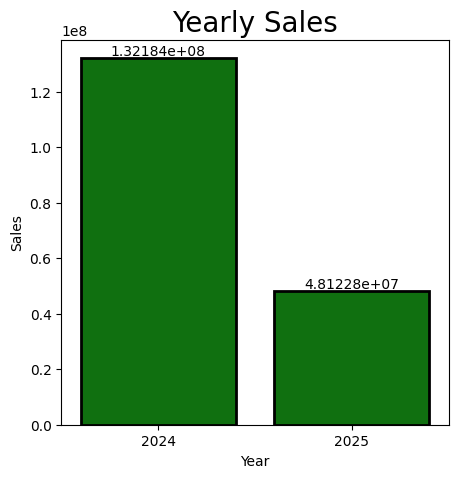

In [48]:
plt.figure(figsize=(5,5))
fig= sns.barplot(x='year',y='sales',data=yearly_sales,color="green",edgecolor = "black",linewidth = 2)
for bars in fig.containers:
    fig.bar_label(bars)
plt.title('Yearly Sales',fontsize = 20)
plt.xlabel('Year')
plt.ylabel('Sales')


Note: Sales generated in year 2025 is lower than sales in year 2024. 

In [49]:
# yearly quantity sold
yearly_quantity_sold =df.groupby('year')['quantity'].sum()
yearly_quantity_sold= pd.DataFrame(yearly_quantity_sold)
yearly_quantity_sold

,quantity
year,
2024,2978
2025,1020


Text(0, 0.5, 'Quantity')

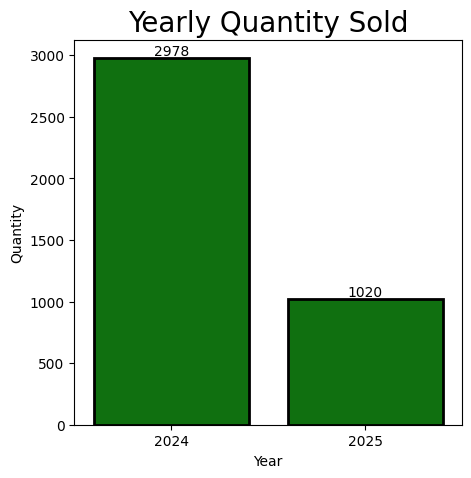

In [50]:
plt.figure(figsize=(5,5))
fig=sns.barplot(x='year', y='quantity', data=yearly_quantity_sold,color='green',edgecolor='black',linewidth=2)
for bars in fig.containers:
    fig.bar_label(bars)
plt.title('Yearly Quantity Sold',fontsize=20)
plt.xlabel('Year')
plt.ylabel("Quantity")

Note: Quantity sold in year 2024 is far more than quantity sold in year 2025.

<Axes: xlabel='month', ylabel='sales'>

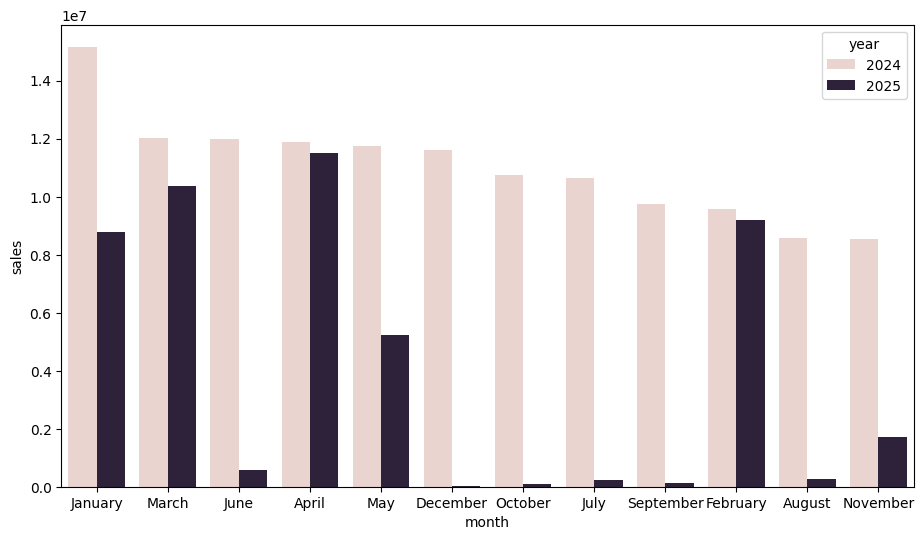

In [51]:
# Monthly and Yearly trend
monthly_trend = df.groupby(["month", 'year'],as_index=False)["sales"].sum().sort_values(by='sales',ascending = False)
monthly_trend=pd.DataFrame(monthly_trend)

plt.figure(figsize=(11,6))
sns.barplot(x='month',y='sales',data=monthly_trend,hue='year')

Note: Year wise monthly sales: In year 2024 month january has the highest no. of sales.


In [52]:
# Monthly Revenue
monthly_revenue= df.groupby('month')['sales'].sum().astype('int')
print((monthly_revenue).sort_values(ascending=False))

month
January      23954444
April        23407574
March        22402855
February     18758840
May          16973370
June         12527838
December     11628278
July         10857666
October      10821482
November     10265780
September     9887844
August        8821098
Name: sales, dtype: int64


Text(0, 0.5, 'Revenue')

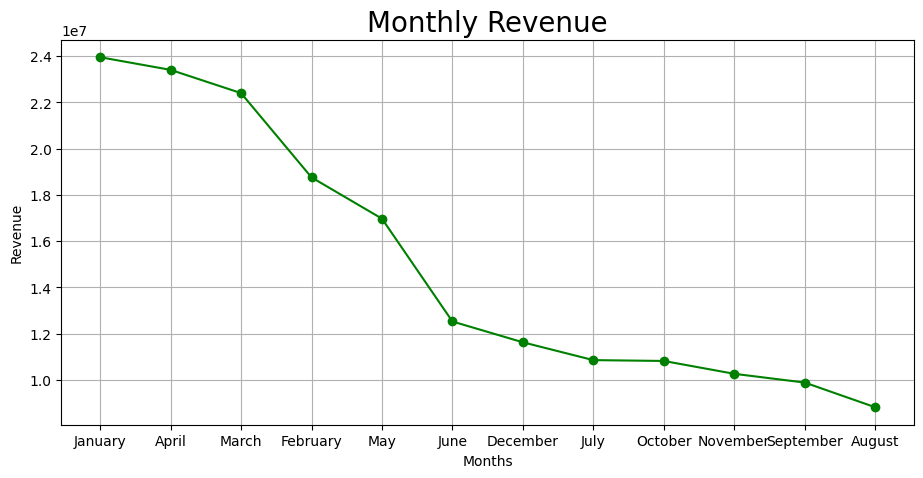

In [53]:
plt.figure(figsize=(11,5))
plt.plot(monthly_revenue.sort_values(ascending=False),marker='o',color='green')
plt.grid(True)
plt.title('Monthly Revenue',fontsize=20)
plt.xlabel('Months')
plt.ylabel('Revenue')

Note: Highest revenue generated month is January

In [54]:
# Monthly Quantity sold
monthly_quantity=df.groupby('month')['quantity'].sum().astype('int')
monthly_quantity.sort_values(ascending=False)

month
January      529
April        528
March        469
February     418
May          386
December     272
June         264
July         251
November     235
October      232
September    211
August       203
Name: quantity, dtype: int64

Text(0, 0.5, 'Quantity')

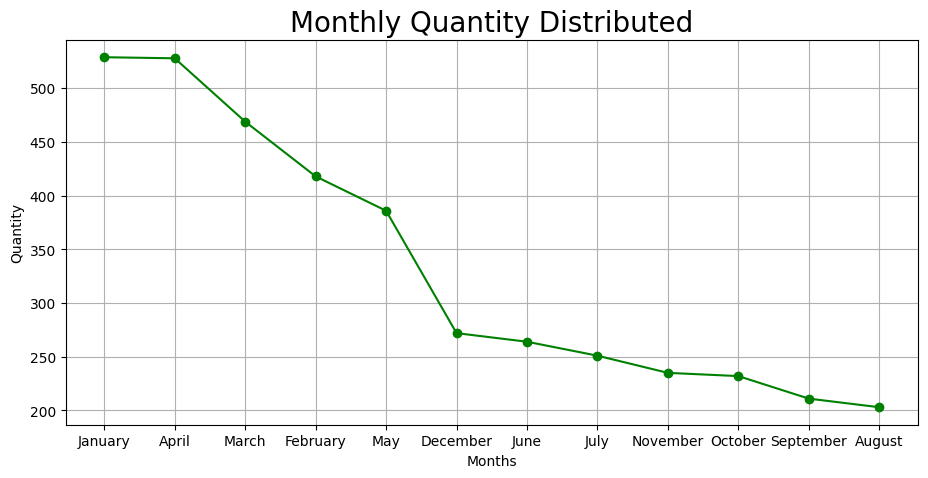

In [55]:
plt.figure(figsize=(11,5))
plt.plot(monthly_quantity.sort_values(ascending=False),marker='o',color='green')
plt.grid(True)
plt.title('Monthly Quantity Distributed',fontsize=20)
plt.xlabel('Months')
plt.ylabel('Quantity')

Note: Highest number of quantity sold is in january month.

In [56]:
# Top Products by Revenue
top_product= df.groupby('product_name')['sales'].sum().head(7).sort_values(ascending=False).astype('int')
top_product=pd.DataFrame(top_product)
top_product

,sales
product_name,
Dell Inspiron,18843554
Laptop Bag,18668110
Lenovo IdeaPad,12570365
Keyboard,10209021
Lenovo Tab,9369424
HP Pavilion,6947494
MacBook Air,1416605


Text(0, 0.5, 'Revenue')

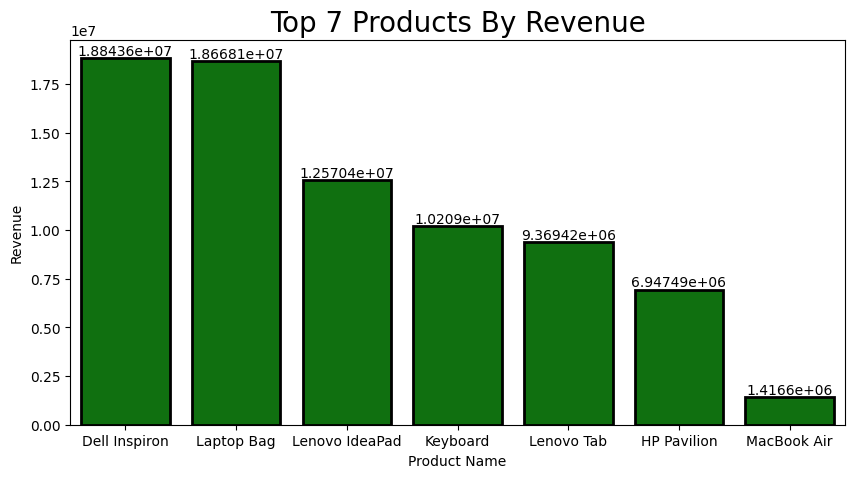

In [57]:
plt.figure(figsize=(10,5))
fig=sns.barplot(x='product_name',y="sales",data=top_product,color='green',edgecolor='black',linewidth=2)
for bars in fig.containers:
    fig.bar_label(bars)
plt.title('Top 7 Products By Revenue',fontsize=20)
plt.xlabel('Product Name')
plt.ylabel('Revenue')

Note: Dell Inspiron and Laptop Bag are two major selling products.

In [58]:
# Top Product By Quantity
top_quantity=df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(7)
top_quantity= pd.DataFrame(top_quantity)
top_quantity

,quantity
product_name,
Wireless Mouse,408
Dell Inspiron,386
Laptop Bag,379
Xiaomi Redmi,373
Samsung Tab,316
Lenovo IdeaPad,284
iPhone 13,281


Text(0, 0.5, 'Quantity')

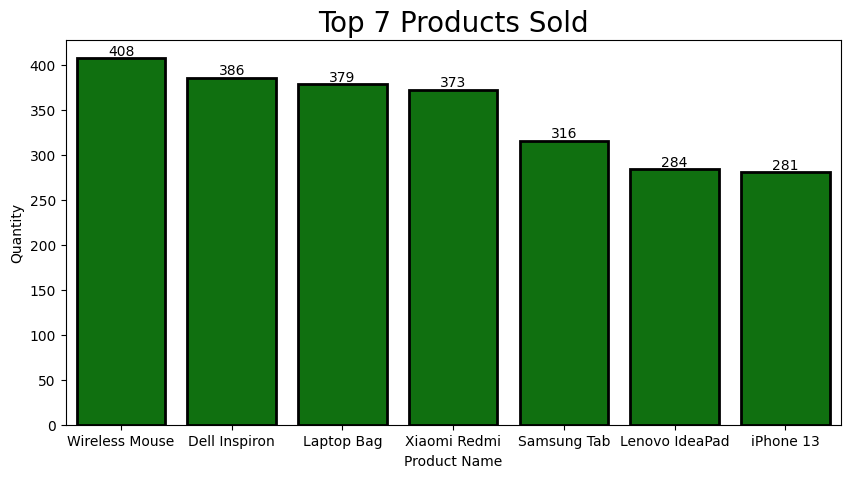

In [59]:
plt.figure(figsize=(10,5))
fig=sns.barplot(x='product_name',y='quantity',data=top_quantity,edgecolor='black',color='green',linewidth=2)
for bars in fig.containers:
    fig.bar_label(bars)
plt.title('Top 7 Products Sold',fontsize=20)
plt.xlabel('Product Name')
plt.ylabel('Quantity')

Note: Wireless mouse is the most selling product.

In [60]:
# Category Sales
category_sales= df.groupby('category')['sales'].sum().astype('int')
category_sales=pd.DataFrame(category_sales)
category_sales

,sales
category,
Accessory,45500907
Laptop,35072600
Smartphone,58883139
Tablet,40850423


Text(0.5, 1.0, 'Category Wise Revenue')

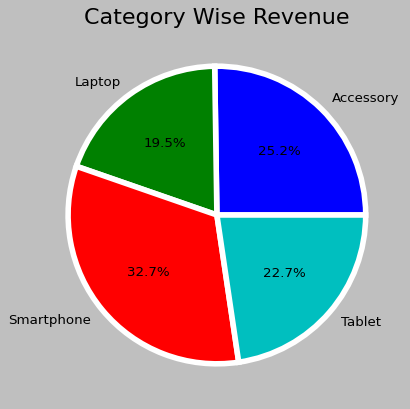

In [61]:
plt.style.use('classic')
plt.figure(figsize=(6,6))
plt.pie(category_sales['sales'],labels=category_sales.index,autopct="%1.1f%%",wedgeprops={'edgecolor':'white','linewidth':5})
plt.title('Category Wise Revenue',fontsize=20)

Note: Smartphone generates highest revenue.

In [62]:
#category wise quantity sold
Category_wise_quantity=df.groupby('category')['quantity'].sum().astype('int')
Category_wise_quantity=pd.DataFrame(Category_wise_quantity)
Category_wise_quantity

,quantity
category,
Accessory,1014
Laptop,781
Smartphone,1287
Tablet,916


Text(0.5, 1.0, 'Category Wise Quantity Sold')

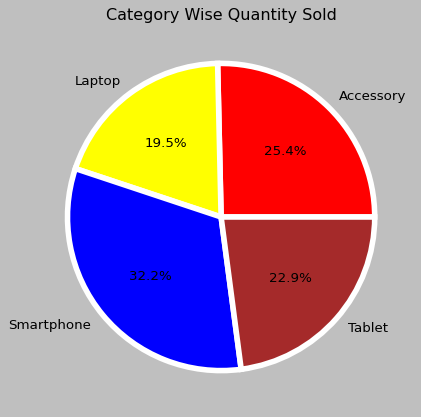

In [63]:
plt.style.use('classic')
plt.pie(Category_wise_quantity['quantity'],labels=Category_wise_quantity.index,autopct='%1.1f%%',
        colors=['red','yellow','blue','brown'],wedgeprops={'edgecolor':'white','linewidth':5})
plt.title('Category Wise Quantity Sold')

Note: Mostly sold category is smartphone.

In [64]:
# City wise sales
city_wise_sales=df.groupby('city')['sales'].sum().astype('int').sort_values(ascending=False)
city_wise_sales=pd.DataFrame(city_wise_sales)
city_wise_sales

,sales
city,
Delhi,49980623
Mumbai,28578466
Hyderabad,24805145
Bangalore,22413901
Pune,15466911
Unknown,14624298
Kolkata,12990615
Chennai,11447110


Text(0, 0.5, 'Sales')

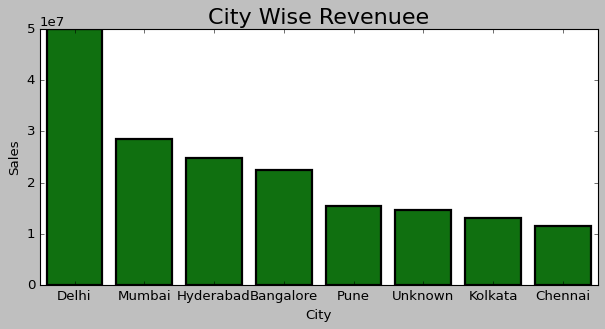

In [65]:
plt.figure(figsize=(9,4))
sns.barplot(x='city',y='sales',data=city_wise_sales,color='green',edgecolor='black',linewidth=2)
plt.title('City Wise Revenuee',fontsize=20)
plt.xlabel('City')
plt.ylabel('Sales')

Note: City Delhi generates highest revenue while chennai generates least revenue.

In [66]:
# Quantity sold in city
city_wise_quantity=df.groupby('city')['quantity'].sum().astype('int').sort_values(ascending=False)
city_wise_quantity=pd.DataFrame(city_wise_quantity)
city_wise_quantity

,quantity
city,
Delhi,1084
Mumbai,657
Hyderabad,537
Bangalore,521
Unknown,346
Pune,338
Kolkata,275
Chennai,240


Text(0, 0.5, 'Quantity')

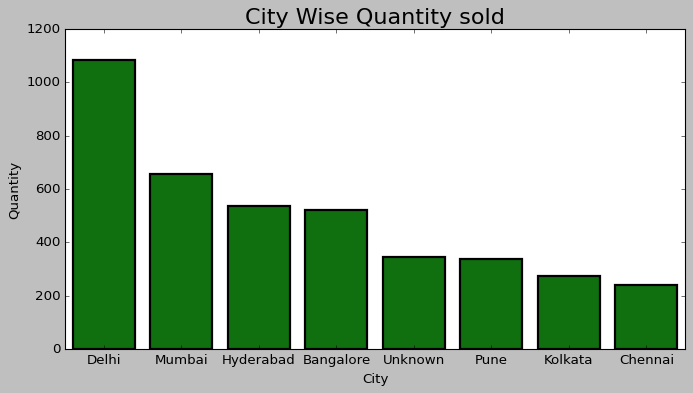

In [67]:
plt.figure(figsize=(10,5))
sns.barplot(x='city',y='quantity',data=city_wise_quantity,color='green',edgecolor='black',linewidth=2)
plt.title('City Wise Quantity sold',fontsize=20)
plt.xlabel('City')
plt.ylabel('Quantity')

Note: City delhi has the highest quantity sold while chennai has least quantity sold.

In [68]:
# Top 5 customers by sales
top_5_customers=df.groupby('customer_id')['sales'].sum().astype('int').sort_values(ascending=False).head(5)
top_5_customers=pd.DataFrame(top_5_customers)
top_5_customers

,sales
customer_id,
C0218,1812433
C0474,1495968
C0142,1494303
C0439,1408115
C0454,1346757


Text(0, 0.5, 'SALES')

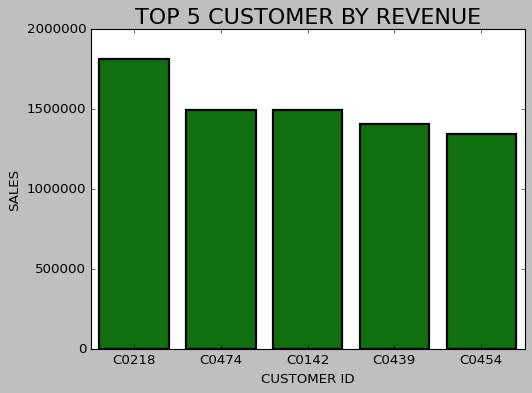

In [69]:
plt.figure(figsize=(7,5))
sns.barplot(x='customer_id',y='sales',data=top_5_customers,color='green',edgecolor='black',linewidth=2)
plt.title('TOP 5 CUSTOMER BY REVENUE',fontsize=20)
plt.xlabel('CUSTOMER ID')
plt.ylabel('SALES')

Note: Among all the customers C0218 recorded highest revenue.

In [70]:
# Top 5 customer by quantity
top_customers=df.groupby('customer_id')['quantity'].sum().astype('int').sort_values(ascending=False).head(5)
top_customers=pd.DataFrame(top_customers)
top_customers

,quantity
customer_id,
C0218,37
C0439,34
C0339,34
C0142,33
C0474,31


Text(0, 0.5, 'QUANTITY')

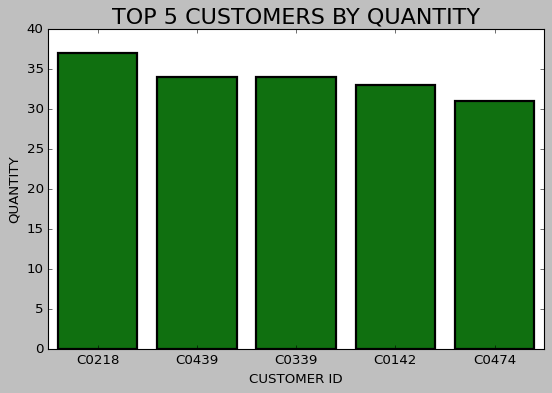

In [71]:
plt.figure(figsize=(8,5))
sns.barplot(x='customer_id',y='quantity',data=top_customers,color='green',edgecolor='black',linewidth=2)
plt.title('TOP 5 CUSTOMERS BY QUANTITY',fontsize=20)
plt.xlabel('CUSTOMER ID')
plt.ylabel('QUANTITY')

Note: C0218 purchased most quantity of product.

In [73]:
# Payment method sales wise
payment_method=df.groupby('payment_method')['sales'].sum().astype('int')
payment_method=pd.DataFrame(payment_method)
payment_method

,sales
payment_method,
Cash,46129910
Credit Card,46148298
Debit Card,21910358
Upi,46439802


Text(0.5, 1.0, 'PAYMENT DISTRIBUTION SALES WISE')

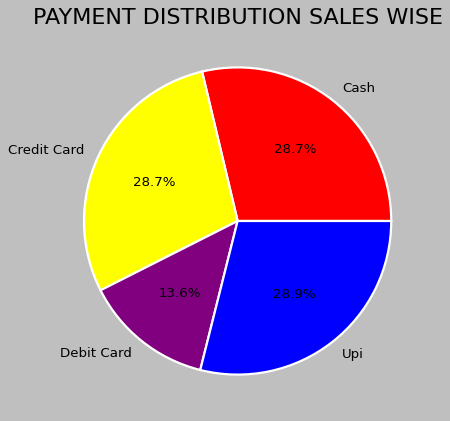

In [74]:
plt.pie(payment_method['sales'],labels=payment_method.index,autopct='%1.1f%%',
        colors=('red','yellow','purple','blue'),wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('PAYMENT DISTRIBUTION SALES WISE',fontsize=20)

Note: Mostly payment received is by UPI.

In [75]:
# Payment method quantity wise
payment_quantity=df.groupby('payment_method')['quantity'].sum().astype('int')
payment_quantity=pd.DataFrame(payment_quantity)
payment_quantity

,quantity
payment_method,
Cash,998
Credit Card,1055
Debit Card,480
Upi,1016


Text(0.5, 1.0, 'PAYMENT DISTRIBUTION QUANTITY WISE')

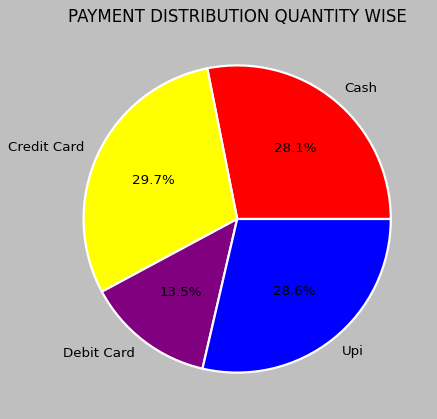

In [76]:
plt.pie(payment_quantity['quantity'],labels=payment_quantity.index,autopct='%1.1f%%',
        colors=('red','yellow','purple','blue'),wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('PAYMENT DISTRIBUTION QUANTITY WISE',fontsize=15)

Note: Payment of highest quantity sold is through credit card.

In [77]:
corr = df.corr(numeric_only=True)
print(corr)

               base_price  order_item_id  quantity  unit_price     sales  \
base_price       1.000000      -0.028743 -0.029882    0.396966  0.182047   
order_item_id   -0.028743       1.000000  0.008615   -0.023365  0.002776   
quantity        -0.029882       0.008615  1.000000   -0.015447  0.761174   
unit_price       0.396966      -0.023365 -0.015447    1.000000  0.527157   
sales            0.182047       0.002776  0.761174    0.527157  1.000000   
year             0.022155      -0.004578  0.018296    0.033748  0.046315   

                   year  
base_price     0.022155  
order_item_id -0.004578  
quantity       0.018296  
unit_price     0.033748  
sales          0.046315  
year           1.000000  


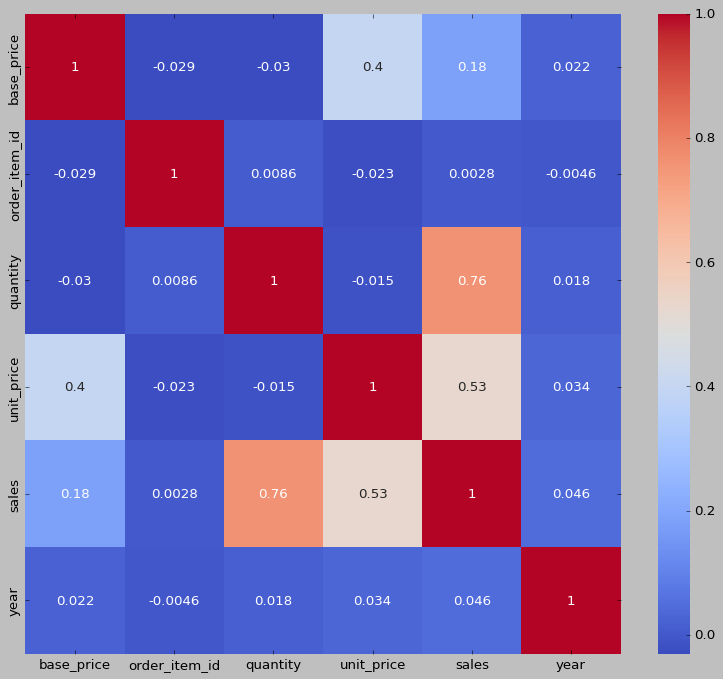

In [78]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Note: There is a strong correlation (0.76) between quantity and sales as quantity increases sales also increases.

## 8) Conclusion